# **BERLIN AIRBNB**

https://www.kaggle.com/datasets/lennarthaupts/airbnb-berlin-july-2021?resource=download

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
from google.colab import drive

drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Datasets/SAA/listings_berlin.csv')
data.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19095 entries, 0 to 19094
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19095 non-null  int64  
 1   name                            19065 non-null  object 
 2   host_id                         19095 non-null  int64  
 3   host_name                       19083 non-null  object 
 4   neighbourhood_group             19095 non-null  object 
 5   neighbourhood                   19095 non-null  object 
 6   latitude                        19095 non-null  float64
 7   longitude                       19095 non-null  float64
 8   room_type                       19095 non-null  object 
 9   price                           19095 non-null  int64  
 10  minimum_nights           

In [34]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1944,bright & airy Pberg/Mitte 3 months or more,2164,Lulah,Mitte,Brunnenstr. Nord,52.54433,13.39761,Private room,28,60,18,2018-11-11,0.21,3,101
1,2015,Berlin-Mitte Value! Quiet courtyard/very central,2217,Ion,Mitte,Brunnenstr. Süd,52.53305,13.40394,Entire home/apt,74,90,141,2020-04-03,2.20,6,357
2,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,90,62,147,2017-03-20,1.14,1,254
3,3309,BerlinSpot Schöneberg near KaDeWe,4108,Jana,Tempelhof - Schöneberg,Schöneberg-Nord,52.49884,13.34940,Private room,29,7,27,2018-08-16,0.28,1,285
4,6883,Stylish East Side Loft in Center with AC & 2 b...,16149,Steffen,Friedrichshain-Kreuzberg,Frankfurter Allee Süd FK,52.51163,13.45289,Entire home/apt,79,7,135,2021-01-02,1.02,1,0


In [35]:
# Nulos -> Pregunta 1
data.isna().sum()

,0
id,0
name,30
host_id,0
host_name,12
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [36]:
data.isnull().mean() * 100

,0
id,0.000000
name,0.157109
host_id,0.000000
host_name,0.062844
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


In [37]:
porcentajes = (data.isnull().sum()/len(data))*100
porcentajes

,0
id,0.000000
name,0.157109
host_id,0.000000
host_name,0.062844
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


# **DATA CLEANING**

Vamos a ver que atributos nos pueden ser de utilidad

## **id, name, host_id y host_name**

In [38]:
# En principio parece que podemos prescindir de id, name, host_id y host_name
data = data.drop(['id', 'name', 'host_id', 'host_name'], axis=1)

## **zona**

Vamos a crear una nueva variable, zona, que puede ser Berlín este o Berlín oeste, o Friedrichshain-Kreuzberg, que comprende tanto Berlín este como Berlín oeste, que usaremos con posterioridad para clasificación

In [39]:
# Vamos a crear una nueva variable

east = ['Treptow - Köpenick', 'Marzahn - Hellersdorf', 'Lichtenberg', 'Pankow', 'Mitte']

data['zona'] = 'west'
for e in east:
    data['zona'][data['neighbourhood_group'] == e] = 'east'
# Hay zonas de Friedrichshain-Kreuzberg que pueden pertenecer tanto a Berlín este como a Berlín oeste
data['zona'][data['neighbourhood_group'] == 'Friedrichshain-Kreuzberg'] = 'Friedrichshain-Kreuzberg'

/tmp/ipython-input-1584351971.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['zona'][data['neighbourhood_group'] == e] = 'east'
/tmp/ipython-input-1584351971.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [40]:
data['zona'].value_counts()

,count
zona,
east,8528
west,6370
Friedrichshain-Kreuzberg,4197


In [41]:
data['zona']=data['zona'].astype('category').cat.codes

## **neighbourhood_group y neighbourhood**

neighbourhood_group hace referencia a 12 diferentes distritos que a su vez contienen barrios (neighbourhood)

In [42]:
data['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Friedrichshain-Kreuzberg,4197
Mitte,4173
Pankow,2981
Neukölln,2608
Charlottenburg-Wilm.,1567
Tempelhof - Schöneberg,1371
Treptow - Köpenick,620
Lichtenberg,612
Steglitz - Zehlendorf,415


In [43]:
# Para simplificar nos quedamos con neighbourhood_group
data['neighbourhood_group']=data['neighbourhood_group'].astype('category').cat.codes
data = data.drop(['neighbourhood'], axis=1)

## **latitude y longitude**

In [44]:
# Parece lógico que el precio dependa de la distancia al centro de Berlín

# Coordenadas del centro de Berlín
berlin = (52.52437, 13.41053)

import geopy.distance
data['to_centre'] = np.nan
for i in data.index:
    data['to_centre'][i] = geopy.distance.distance(berlin, (data['latitude'][i], data['longitude'][i])).km

Se han truncado las últimas 5000 líneas del flujo de salida.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['to_centre'][i] = geopy.distance.distance(berlin, (data['latitude'][i], data['longitude'][i])).km
/tmp/ipython-input-589933909.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['to_centre'][i] = geopy.distance.distance(berlin, (data['latitude'][i], data['longitude'][i])).km
/tmp/ipython-input-589933909.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the or

In [45]:
data = data.drop(['latitude', 'longitude'], axis=1)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19095 entries, 0 to 19094
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             19095 non-null  int8   
 1   room_type                       19095 non-null  object 
 2   price                           19095 non-null  int64  
 3   minimum_nights                  19095 non-null  int64  
 4   number_of_reviews               19095 non-null  int64  
 5   last_review                     14940 non-null  object 
 6   reviews_per_month               14940 non-null  float64
 7   calculated_host_listings_count  19095 non-null  int64  
 8   availability_365                19095 non-null  int64  
 9   zona                            19095 non-null  int8   
 10  to_centre                       19095 non-null  float64
dtypes: float64(2), int64(5), int8(2), object(2)
memory usage: 1.3+ MB


## **room_type**

In [47]:
data['room_type'].value_counts()

,count
room_type,
Entire home/apt,10636
Private room,8042
Shared room,249
Hotel room,168


In [48]:
data['room_type']=data['room_type'].astype('category').cat.codes

In [49]:
# One Hot Encoding -> Pregunta 2
# One Hot Encoding es una técnica para convertir variables categóricas en variables numéricas binarias (0/1), necesarias para muchos modelos de ML.

df_encoded = pd.get_dummies(data, columns=['room_type'], drop_first=True)

df_encoded.head()

,neighbourhood_group,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,zona,to_centre,room_type_1,room_type_2,room_type_3
0,4,28,60,18,2018-11-11,0.21,3,101,1,2.387867,False,True,False
1,4,74,90,141,2020-04-03,2.20,6,357,1,1.064406,False,False,False
2,6,90,62,147,2017-03-20,1.14,1,254,1,1.260089,False,False,False
3,10,29,7,27,2018-08-16,0.28,1,285,2,5.029451,False,True,False
4,1,79,7,135,2021-01-02,1.02,1,0,0,3.205980,False,False,False


## **number_of_reviews, last_review y reviews_per_month**

In [50]:
porcentajes = (data.isnull().sum()/len(data))*100
porcentajes

,0
neighbourhood_group,0.000000
room_type,0.000000
price,0.000000
minimum_nights,0.000000
number_of_reviews,0.000000
last_review,21.759623
reviews_per_month,21.759623
calculated_host_listings_count,0.000000
availability_365,0.000000
zona,0.000000


In [51]:
# Cuando last_review y reviews_per_month están a nulos es porque todavía no ha tenido ninguna visualización
data = data.dropna()

In [52]:
# De la fecha de la última visualización nos quedamos con el año
data['last_review'] = data['last_review'].str.slice(stop=4).astype('float64')

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14940 entries, 0 to 19033
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             14940 non-null  int8   
 1   room_type                       14940 non-null  int8   
 2   price                           14940 non-null  int64  
 3   minimum_nights                  14940 non-null  int64  
 4   number_of_reviews               14940 non-null  int64  
 5   last_review                     14940 non-null  float64
 6   reviews_per_month               14940 non-null  float64
 7   calculated_host_listings_count  14940 non-null  int64  
 8   availability_365                14940 non-null  int64  
 9   zona                            14940 non-null  int8   
 10  to_centre                       14940 non-null  float64
dtypes: float64(3), int64(5), int8(3)
memory usage: 1.1 MB


In [54]:
# Enferencia Valores Nulos -> Pregunta 3

data['reviews_per_month'].fillna(data['reviews_per_month'].median(), inplace=True) # -> Primer caso, los reemplazamos por la mediana

data['has_review'] = data['last_review'].notnull().astype(int) # -> Segundo Caso, cambiamos el tipo de variable a una binaria si tiene o no review
data.drop(columns=['last_review'], inplace=True)

/tmp/ipython-input-367563786.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['reviews_per_month'].fillna(data['reviews_per_month'].median(), inplace=True) # -> Primer caso, los reemplazamos por la mediana


## **Variable objetivo: price**

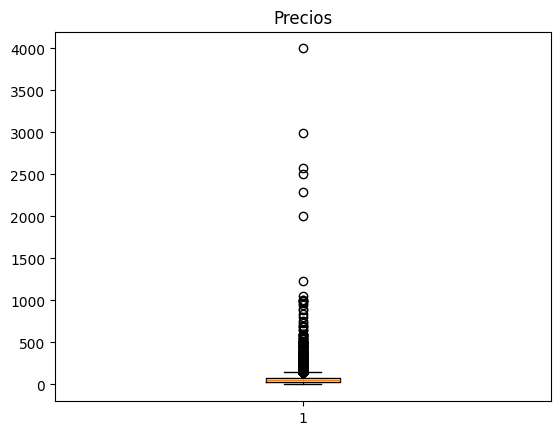

In [55]:
plt.boxplot(data['price'])
plt.title("Precios")
plt.show()

In [56]:
# Vemos que hay muchos outliers
# 99% de los precios está por debajo de 300 euros, aproximadamente
data['price'].quantile(0.99)

np.float64(299.0)

In [57]:
# Vamos a eliminar aquellos registros con precio igual a 0 o superior a 300 para que no nos distorsione los resultados
data = data[data['price']<=300]
data = data[data['price']>0]

In [58]:
data.describe()

,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,zona,to_centre,has_review
count,14806.000000,14806.000000,14806.000000,14806.000000,14806.000000,14806.000000,14806.000000,14806.000000,14806.000000,14806.000000,14806.0
mean,4.219776,0.893151,65.184250,8.030461,27.637377,0.717860,2.668445,86.240916,1.108199,4.754775,1.0
std,2.982657,1.009210,44.968027,32.285343,53.550624,1.449207,6.342085,123.300350,0.737506,3.177936,0.0
min,0.000000,0.000000,8.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,0.027850,1.0
25%,1.000000,0.000000,35.000000,2.000000,2.000000,0.090000,1.000000,0.000000,1.000000,2.788865,1.0
50%,4.000000,0.000000,50.000000,3.000000,7.000000,0.270000,1.000000,0.000000,1.000000,4.157607,1.0
75%,6.000000,2.000000,80.000000,5.000000,25.000000,0.830000,2.000000,163.000000,2.000000,5.826992,1.0
max,11.000000,3.000000,300.000000,1124.000000,620.000000,94.350000,76.000000,365.000000,2.000000,26.163171,1.0


# **REDUCCIÓN DIMENSIONALIDAD**

## **CORRELACIÓN**

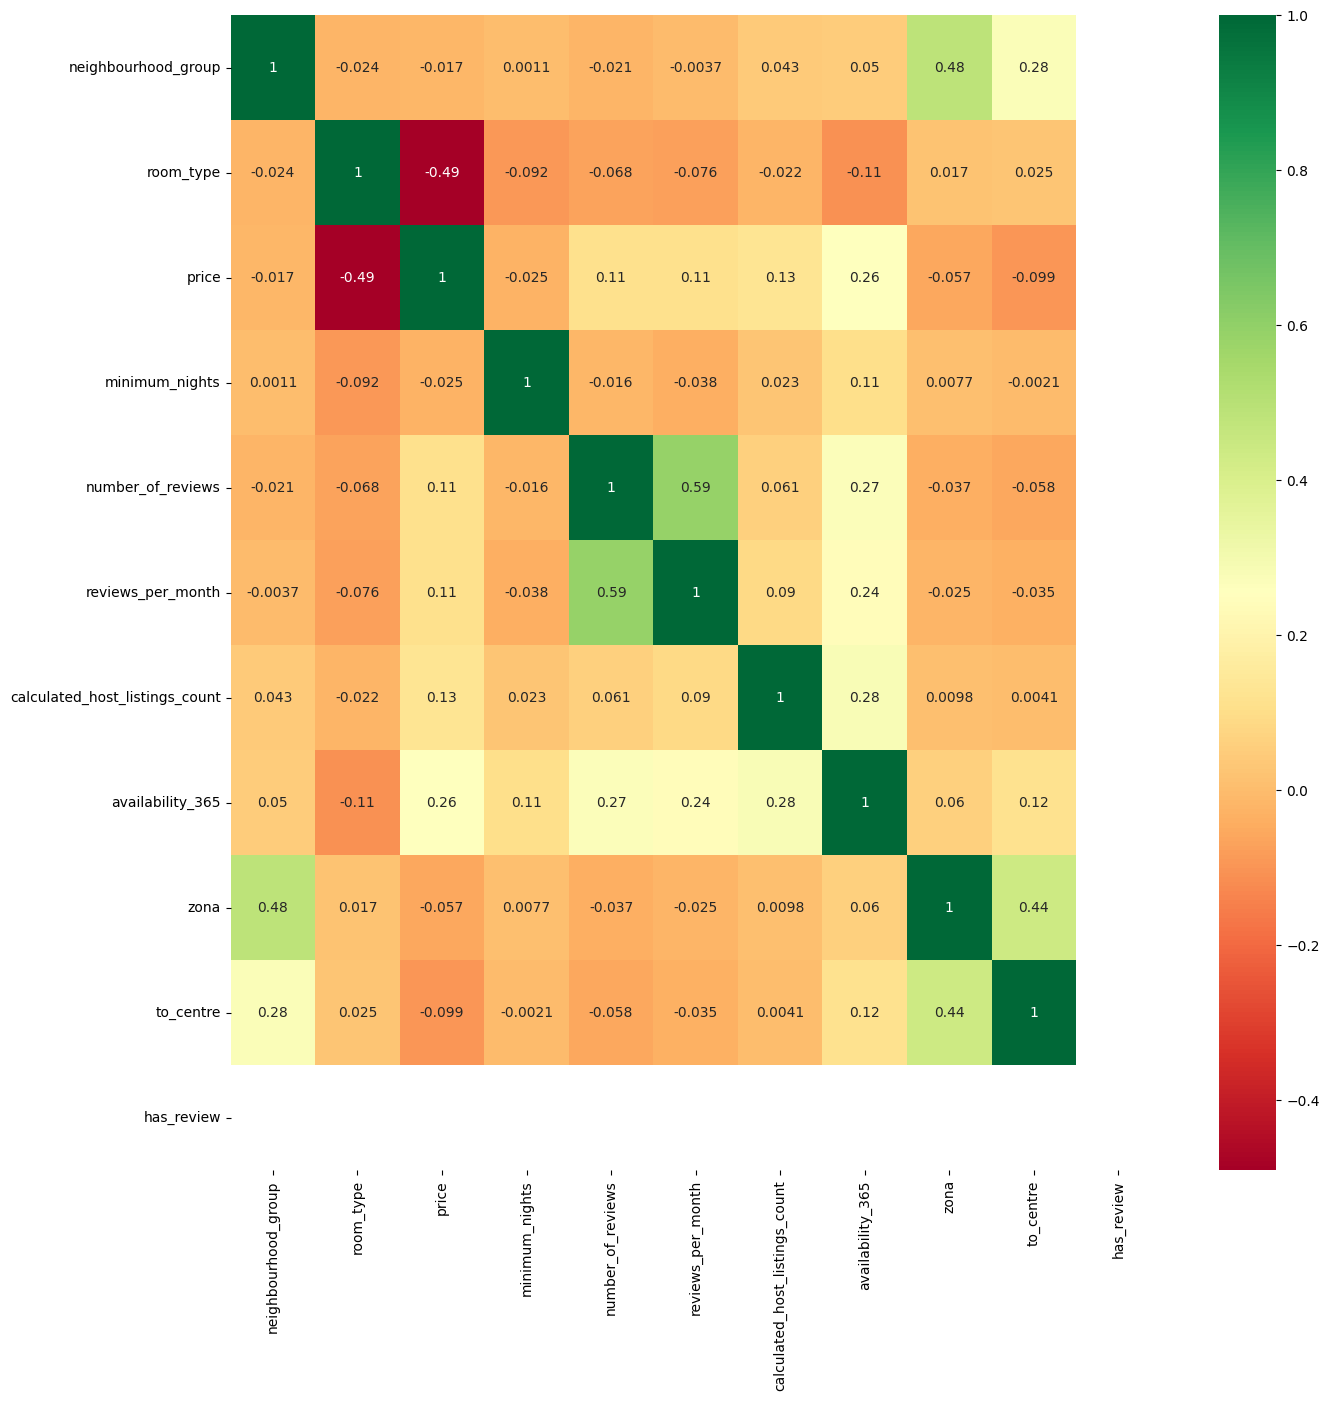

In [59]:
plt.figure(figsize=(15,15))
g=sns.heatmap(data.corr(), annot=True, cmap="RdYlGn")

In [60]:
# Como reviews_per_month y number_of_reviews están correlacionadas nos quedamos con una de ellas
data = data.drop(['reviews_per_month'], axis=1)

## **PCA**

In [62]:
X = data[['neighbourhood_group', 'room_type', 'minimum_nights', 'number_of_reviews', 'has_review', 'calculated_host_listings_count', 'availability_365', 'to_centre']]
y = data['price']

In [63]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)

In [64]:
from sklearn.decomposition import PCA

pca_8 = PCA(n_components=8)
pca_8.fit(X_scaled)
X_pca_8 = pca_8.transform(X_scaled)

print("shape of X_pca_8", X_pca_8.shape)
expl = pca_8.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:5]))

shape of X_pca_8 (14806, 8)
[0.21413963 0.18310053 0.15081426 0.13714855 0.12558592 0.10627086
 0.08294025 0.        ]
suma: 0.8107888913529628


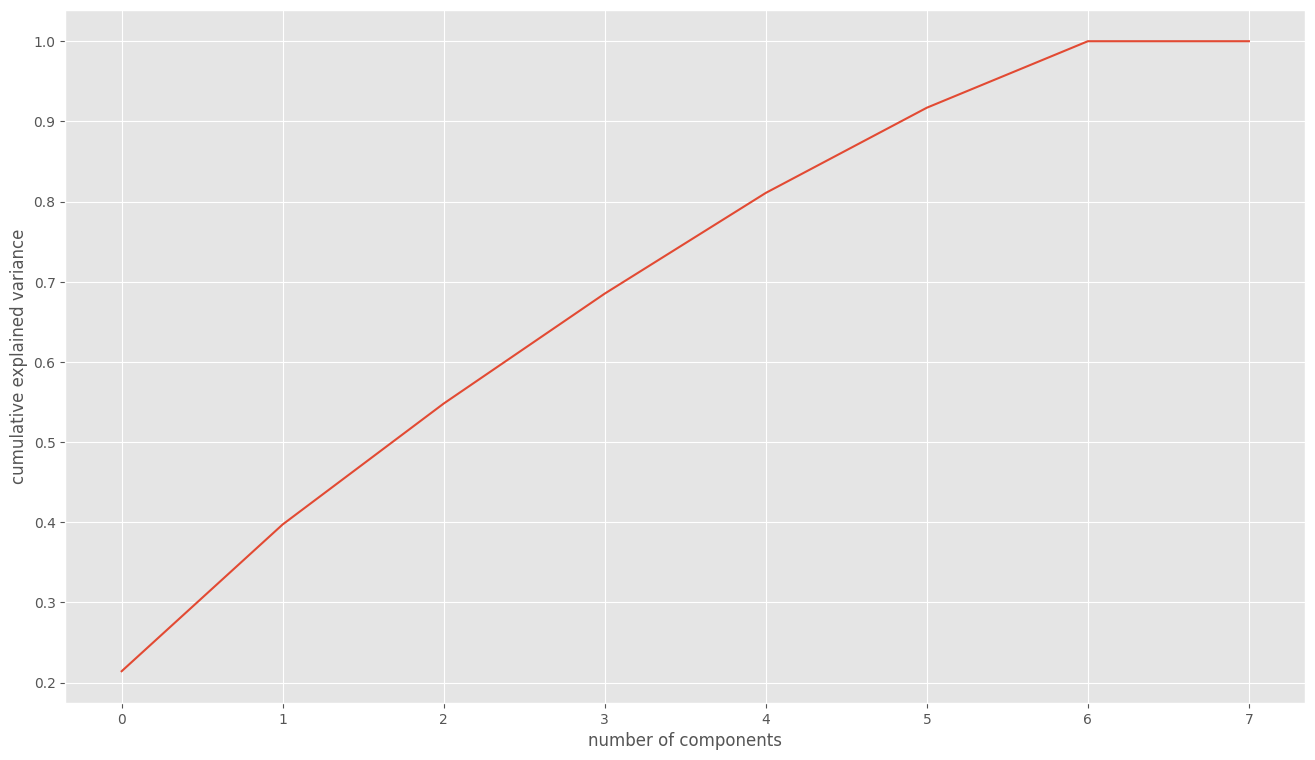

In [65]:
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
plt.plot(np.cumsum(pca_8.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

# **SUPERVISADO (REGRESIÓN)**
El objetivo es predecir el precio

## **REGRESIÓN LINEAL MÚLTIPLE**

### **Con 8 componentes**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

X = data[['neighbourhood_group', 'room_type', 'minimum_nights', 'number_of_reviews', 'last_review', 'calculated_host_listings_count', 'availability_365', 'to_centre']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)

print('Coeficientes : \n', regr.coef_)

print('Error medio cuadrático: %.2f'
      % mean_squared_error(y_test, y_pred))

# Coeficiente de determinación -> va entre 0 y 1, nos indica cuanto podemos explicar con nuestro algoritmo
# Puede considerarse aceptable a partir de un 0.65, sin embargo 0.7 - 0.8 son valores deseables.
print('Coeficiente de determinación: %.2f'
      % r2_score(y_test, y_pred))

Coeficientes : 
 [-1.40827724e-01 -2.07886405e+01 -1.43629027e-01 -2.97646216e-03
  1.79199063e+00  4.59655237e-01  7.11611027e-02 -1.57026623e+00]
Error medio cuadrático: 1371.08
Coeficiente de determinación: 0.31


### **Con reducción de componentes con PCA**

In [ ]:
# Redución Componentes PCA -> Pregunta 4

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

X = data.values
y = data['price']

# Es obligatorio escalar para PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Aplicar PCA con 5 componentes
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# 3. División de datos y Entrenamiento
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)

# 4. Resultados
print(f"Varianza explicada total por los 5 componentes: {sum(pca.explained_variance_ratio_):.2f}")
print('Error medio cuadrático (PCA): %.2f' % mean_squared_error(y_test, y_pred_pca))
print('Coeficiente de determinación (PCA): %.2f' % r2_score(y_test, y_pred_pca))

Varianza explicada total por los 5 componentes: 0.75
Error medio cuadrático (PCA): 460.12
Coeficiente de determinación (PCA): 0.77


## **SVR (Support Vector Regresion)**

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score

X = data.loc[:, ['neighbourhood_group', 'room_type', 'minimum_nights', 'number_of_reviews', 'has_review', 'calculated_host_listings_count', 'availability_365', 'to_centre']]
y = data.loc[:, 'price']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9)

clf = SVR(kernel='rbf')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred

array([66.32042355, 46.33095316, 54.28026578, ..., 57.44504614,
       48.66218454, 44.78548178])

In [80]:
# Métricas SVR -> Pregunta 5

# Para evaluar un modelo SVR se utilizan métricas de regresión como MAE, MSE, RMSE y R², ya que el objetivo es predecir un valor numérico continuo
# (el precio del alojamiento). Estas métricas permiten medir el error medio en euros y la capacidad del modelo para explicar la variabilidad del
# precio en función de características como el barrio, el tipo de habitación o la disponibilidad anual.

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 29.028430204375685
RMSE: 44.825642610466836
R2: 0.0226349962270167


## **DECISION TREE**


In [ ]:
X = data[['neighbourhood_group', 'room_type', 'minimum_nights', 'number_of_reviews', 'last_review', 'calculated_host_listings_count', 'availability_365', 'to_centre']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn import tree

clf = tree.DecisionTreeRegressor(random_state=0)
clf = clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)
y_pred

array([130.,  65.,  45., ...,  23.,  45.,  32.])

# **SUPERVISADO (CLASIFICACIÓN)**
El objetivo es clasificar las ofertas en dos zonas (este y oeste de Berlín), más otra que está entre este y oeste.

## **SVC**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14806 entries, 0 to 19033
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             14806 non-null  int8   
 1   room_type                       14806 non-null  int8   
 2   price                           14806 non-null  int64  
 3   minimum_nights                  14806 non-null  int64  
 4   number_of_reviews               14806 non-null  int64  
 5   last_review                     14806 non-null  float64
 6   calculated_host_listings_count  14806 non-null  int64  
 7   availability_365                14806 non-null  int64  
 8   zona                            14806 non-null  int8   
 9   to_centre                       14806 non-null  float64
dtypes: float64(2), int64(5), int8(3)
memory usage: 968.8 KB


In [ ]:
X = data.loc[:, ['neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'calculated_host_listings_count', 'availability_365', 'to_centre']]
y = data.loc[:, 'zona']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.svm import SVC

classifier =  SVC(kernel="linear", C=0.025)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_pred


array([2, 0, 1, ..., 0, 1, 1], dtype=int8)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       650
           1       0.87      0.78      0.82      1334
           2       0.73      0.83      0.78       978

    accuracy                           0.84      2962
   macro avg       0.86      0.87      0.86      2962
weighted avg       0.85      0.84      0.84      2962



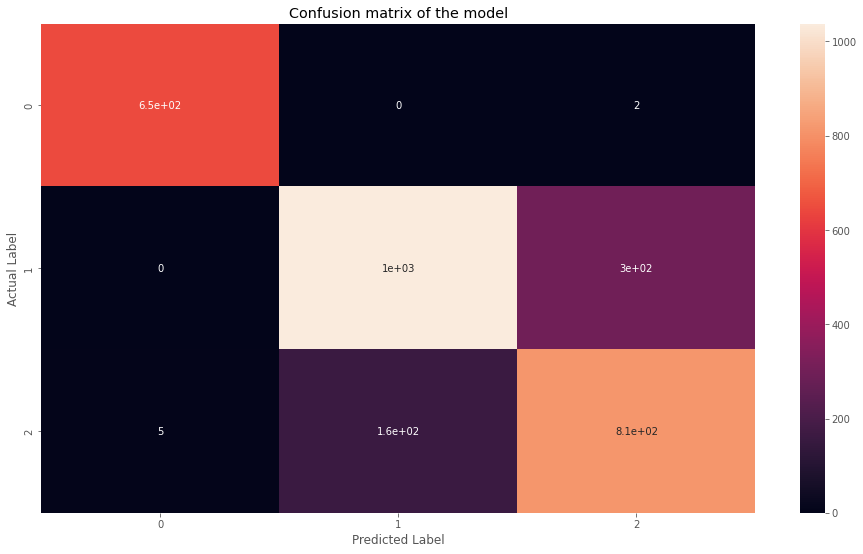

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, plot_confusion_matrix

conf_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_mat, annot=True)
plt.xlabel("Predicted Label")
plt.ylabel('Actual Label')
plt.title('Confusion matrix of the model')
plt.show()

In [ ]:
# Métricas SVC -> Pregunta 6

In [ ]:
# Para evaluar un modelo SVC se utilizan métricas de clasificación como accuracy, precision, recall y F1-score, además de la matriz de confusión.
# En el supuesto, estas métricas permiten medir qué porcentaje de alojamientos se asignan correctamente a su zona,
# cuántos alojamientos de cada zona se identifican correctamente y qué zonas se confunden entre sí.

## **DECISION TREE**

In [ ]:
# Decision Tree -> Pregunta 7

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Variables predictoras y variable objetivo
X = data.loc[:, [
    'neighbourhood_group',
    'room_type',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'calculated_host_listings_count',
    'availability_365',
    'to_centre'
]]

y = data.loc[:, 'zona']

# División train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo Decision Tree
dt = DecisionTreeClassifier(
    criterion="gini",      # medida de impureza
    max_depth=6,           # evita overfitting
    random_state=42
)

dt.fit(X_train, y_train)

# Predicciones
y_pred = dt.predict(X_test)


In [83]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9972991222147198

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       696
           1       1.00      1.00      1.00      1307
           2       1.00      0.99      1.00       959

    accuracy                           1.00      2962
   macro avg       1.00      1.00      1.00      2962
weighted avg       1.00      1.00      1.00      2962



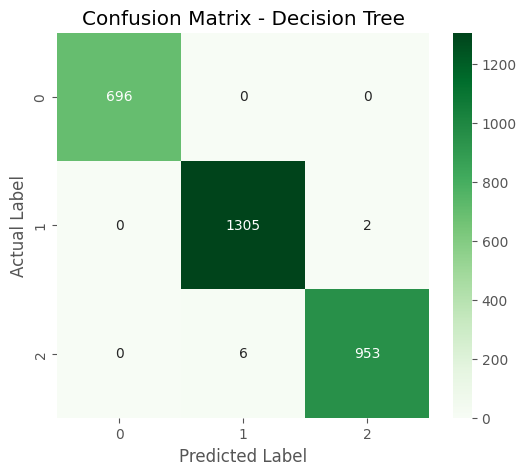

In [84]:
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()


In [ ]:
# Datos Balanceados - Regresión y Clasificación -> Pregunta 8

In [ ]:
# En regresión no se habla de datos balanceados porque la variable objetivo es continua y no existen clases.
# En este caso se analiza la distribución del precio, que suele estar sesgada con valores extremos.

# En clasificación, sí existe el concepto de balanceo, ya que la variable objetivo es categórica.
# En el supuesto, las zonas con más alojamientos están sobrerrepresentadas, lo que provoca un conjunto de datos desbalanceado y obliga a usar métricas como precision, recall y F1-score en lugar de solo accuracy.